In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

In [86]:
import pickle

In [46]:
def read_frame(file_name="../data/green_tripdata_2021-01.parquet"):
    df = pd.read_parquet(file_name)

    duration =  df.lpep_dropoff_datetime - df.lpep_pickup_datetime 
    df.loc[:,"duration"] = duration

    df.duration = df.duration.apply(lambda td: td.total_seconds()/60)
    df  = df[((df.duration >=1) & (df.duration<=60))]

    categorical_variables = ['PULocationID', 'DOLocationID']

    df[categorical_variables] = df[categorical_variables].astype(str)
    
    return df

In [47]:
df_train = read_frame()
df_val = read_frame(file_name="../data/green_tripdata_2021-02.parquet")


In [48]:
len(df_train), len(df_val)

(73908, 61921)

In [80]:
df_train["PU_DO"] = df_train['PULocationID']+"_"+ df_train['DOLocationID']
df_val["PU_DO"] = df_val['PULocationID']+"_"+ df_val['DOLocationID']

In [81]:
numerical = ["trip_distance"]
categorical_variables = ["PU_DO"]#['PULocationID', 'DOLocationID']

train_dict = df_train[categorical_variables+numerical].to_dict(orient="records")
dv = DictVectorizer()
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical_variables+numerical].to_dict(orient="records")
X_val = dv.transform(val_dict)



In [82]:
target = "duration"
y_train = df_train[target].values
y_val = df_val[target].values

In [83]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)


mean_squared_error(y_val, y_pred)

60.19766170466965

In [84]:
lr = Lasso(alpha=0.0001)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)


mean_squared_error(y_val, y_pred)

58.01286611864446

In [89]:
with open("../models/lasso_reg.bin", "wb") as f:
    pickle.dump((dv, lr), f)

In [85]:
# lr = Ridge(alpha=2)

# lr.fit(X_train, y_train)

# y_pred = lr.predict(X_val)


# mean_squared_error(y_val, y_pred)

62.406767974201315

96.80198150112653

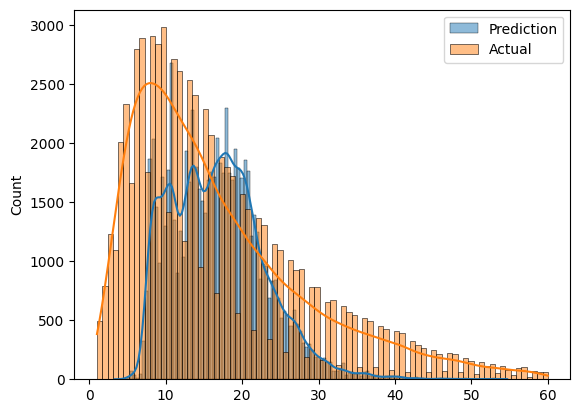

In [34]:


fig, ax = plt.subplots()
sns.histplot(y_pred, label='Prediction', ax=ax, kde=True)
sns.histplot(y_train, label='Actual', ax=ax, kde=True)

ax.legend()
plt.show()


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)